# Important Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set global font sizes

In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 13,        # x and y axis label size
    'xtick.labelsize': 13,       # X tick label size
    'ytick.labelsize': 13,       # Y tick label size
    'legend.fontsize': 13,       # Legend text size
    'figure.titlesize': 13,      # Main figure title
    'legend.fontsize': 13        # Legend text size
})


# Sensitivity Analysis

In [4]:
############################################################################################
# Define a function for sensitivity_analysis
#=========================================================###=========================================================#

def sensitivity_analysis_1(q_10, q_01, T_simulation_1, rate_1, expected_output_1):
    # computer the stationary distribution
    pi_1 = q_01 /(q_10+q_01)
    pi_0 = q_10 /(q_10+q_01)

    # expected undisrupted time
    T_undisrupted = pi_1 * T_simulation_1
    T_disrupted = pi_0 * T_simulation_1
    
    # System output (base rate = 100 units/day) ---
    System_output_1 = rate_1 * pi_1       # undisrupted
    System_output_2 = rate_1 * pi_0       # disrupted
    
    # Mean Completion Time
    Mean_Completion = expected_output_1/System_output_1
    
    return pi_0, pi_1, T_undisrupted, T_disrupted, System_output_1, System_output_2, Mean_Completion 

disruption_rates_1 = np.linspace(0.001, 0.3, 10)   # disruption rate ## q_10
q_01 = 0.1                                         # repair rate
T_simulation_1 = 50                                  # total time horizon
rate_1 = 100                                          # production rate
expected_output_1 = 2000                              # target units

# Lists to store results
pi_0_list = []
pi_1_list = []
T_undisrupted_list = []
T_disrupted_list = []
System_output_1_list = []
System_output_2_list = []
Mean_Completion_list = []

#=========================================================###=========================================================#
for q_10 in disruption_rates_1:
    pi_0, pi_1, T_undisrupted, T_disrupted, System_output_1, System_output_2, Mean_Completion = sensitivity_analysis_1(q_10, q_01, 
                                                                                                    T_simulation_1, rate_1, expected_output_1)
    pi_0_list.append(pi_0)
    pi_1_list.append(pi_1)
    T_undisrupted_list.append(T_undisrupted)
    T_disrupted_list.append(T_disrupted)
    System_output_1_list.append(System_output_1)
    System_output_2_list.append(System_output_2)
    Mean_Completion_list.append(Mean_Completion)    

# Code for Availability, Throughput (System output), Mean Completion Time and Expected Undisrupted time

In [5]:
# Define a function for sensitivity_analysis
#======================###======================

def sensitivity_analysis_2(q_10, q_01, T_simulation, production_rate, target_units):

# Availability proportion
#======================###======================
    Availability = q_01 /(q_10 + q_01)    
    
    
# Throughput (System output) (base rate = 100 units/day) ---
#======================###======================
    Throughput = production_rate * Availability
    
    
# Mean Completion Time
#======================###======================
    MeanCompletion = target_units/Throughput
    
# expected undisrupted time
#======================###======================
    T_undisrupted = Availability * T_simulation
    
    return Availability, Throughput, MeanCompletion, T_undisrupted



#============================= Define grid =================================#
disruption_rates = np.linspace(0.001, 0.3, 10)          # disruption rate q_{1,0}
repair_rates = np.linspace(0.1, 0.3, 10)                # repair rate q_{0,1}
Q10, Q01 = np.meshgrid(disruption_rates, repair_rates)   # generate 2D matrices
T_simulation = 50                                       # total time horizon
production_rate = 100                                    # production rate
target_units = 2000                                      # Targeted output

# Create empty 2D arrays matching the grid
Availability_grid = np.zeros_like(Q10)
Throughput_grid = np.zeros_like(Q10)
MeanCompletion_grid = np.zeros_like(Q10)
T_undisrupted_grid = np.zeros_like(Q10)


#========================= Fill the grids ==================================#
for i in range(len(repair_rates)):
    for j in range(len(disruption_rates)):
        
        q_10 = disruption_rates[j]
        q_01 = repair_rates[i]
        
        Availability, Throughput, MeanCompletion, T_undisrupted = sensitivity_analysis_2(q_10, q_01, 
                                                                        T_simulation, production_rate, target_units)
        
        Availability_grid[i, j] = Availability
        Throughput_grid[i, j] = Throughput
        MeanCompletion_grid[i, j] = MeanCompletion
        T_undisrupted_grid[i, j] = T_undisrupted

# - Contour Plot for Availability

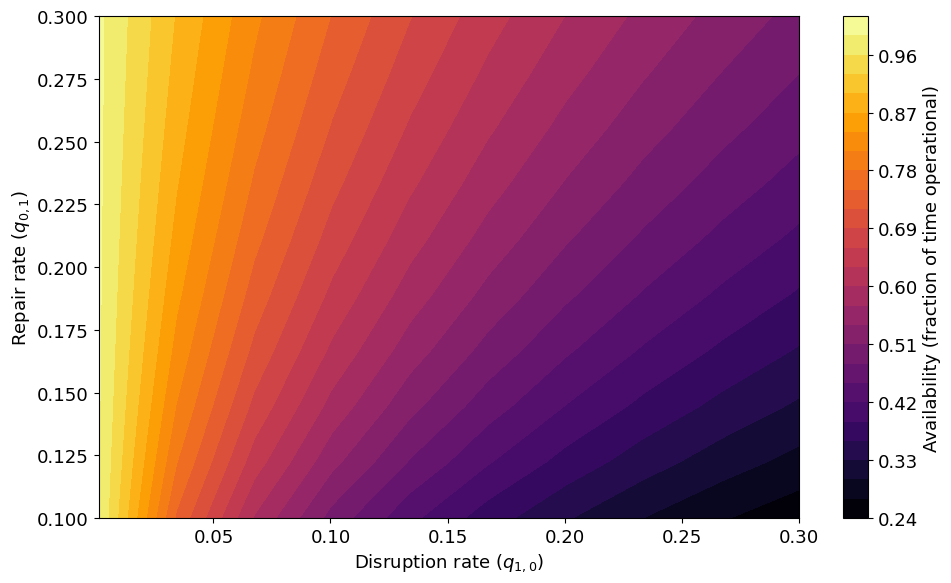

In [6]:
# ========== Plot 1: Availability ==========
plt.figure(figsize=(10,6))
cs1 = plt.contourf(Q10, Q01, Availability_grid, levels=25, cmap="inferno")
plt.colorbar(cs1, label="Availability (fraction of time operational)")
plt.xlabel(r"Disruption rate $(q_{1,0})$")
plt.ylabel(r"Repair rate $(q_{0,1})$")
# plt.title("Contour Plot of Availability")
plt.grid(False)
plt.tight_layout()
plt.savefig("availability_contour_plot.png", format='png', bbox_inches='tight')

plt.show()

# Stationary distribution line plot and Availability contour plot

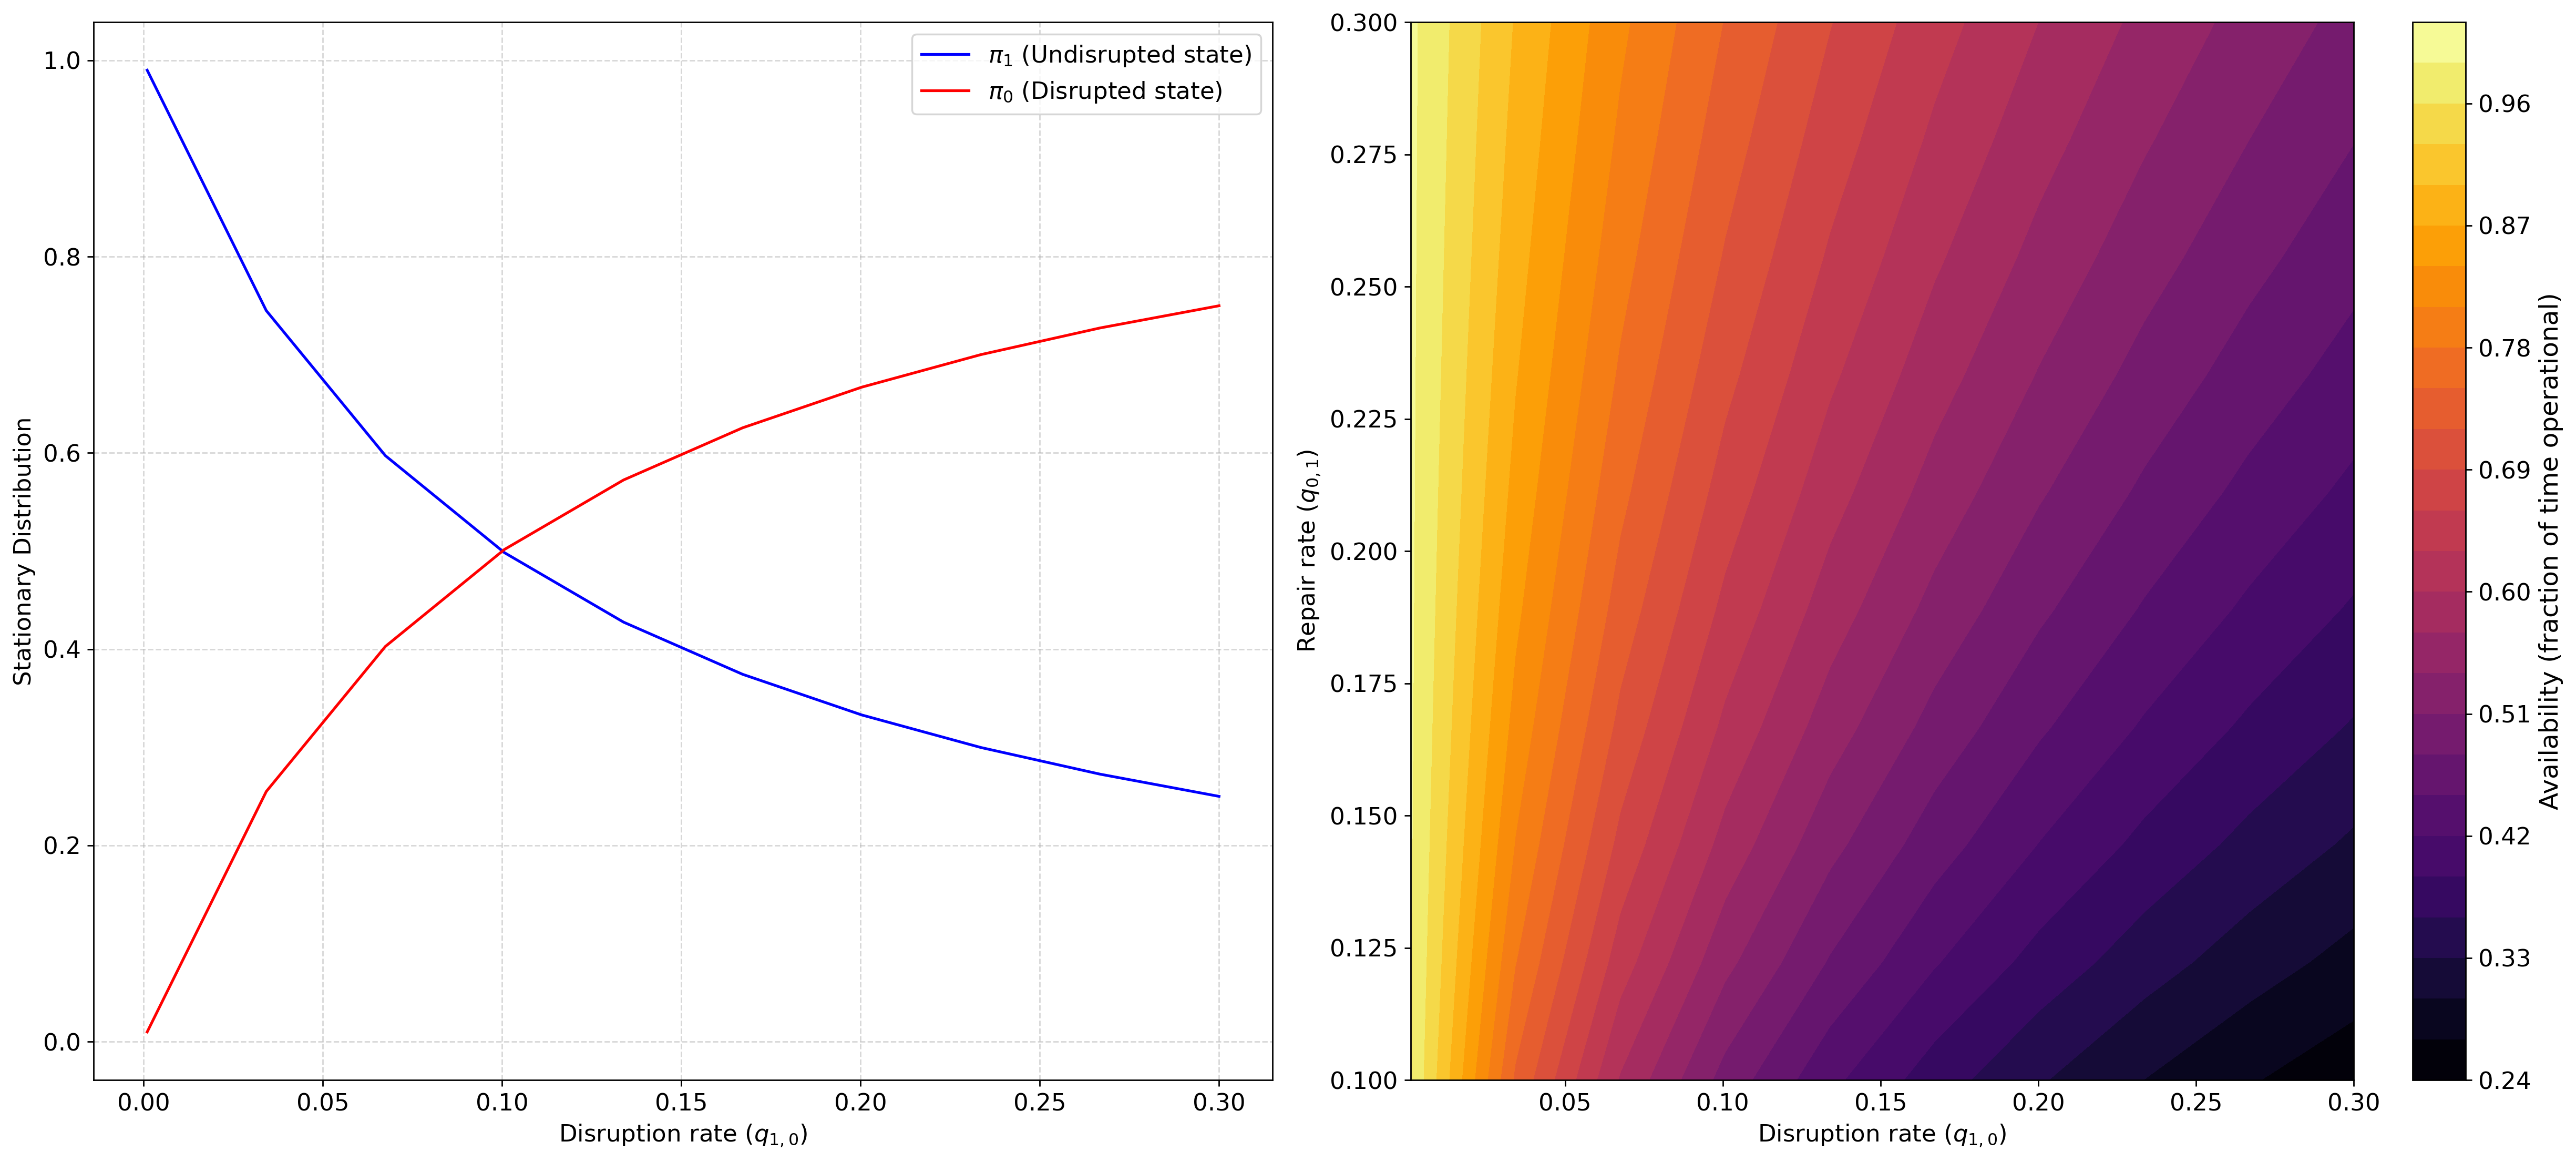

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Stationary distribution line plot
# ============================================================
ax = axes[0]

ax.plot(disruption_rates_1, pi_1_list, color="blue", linewidth=1.5, label=r"$\pi_1$ (Undisrupted state)")
ax.plot(disruption_rates, pi_0_list, color="red", linewidth=1.5, label=r"$\pi_0$ (Disrupted state)")

ax.set_xlabel(r"Disruption rate ($q_{1,0}$)")
ax.set_ylabel("Stationary Distribution")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
# ax.set_title("Stationary Distribution vs Disruption Rate")


# ============================================================
#  RIGHT PANEL — Availability contour plot
# ============================================================
ax = axes[1]

cs1 = ax.contourf(Q10, Q01, Availability_grid, levels=25, cmap="inferno")
cbar = fig.colorbar(cs1, ax=ax)
cbar.set_label("Availability (fraction of time operational)", fontsize=14)

ax.set_xlabel(r"Disruption rate $(q_{1,0})$")
ax.set_ylabel(r"Repair rate $(q_{0,1})$")
# ax.set_title("Contour Plot of Availability")
ax.grid(False)



# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()

plt.savefig("availability_line_contour_plot.png", format='png', bbox_inches='tight')
plt.show()


# - Contour Plot for Throughput (System output)

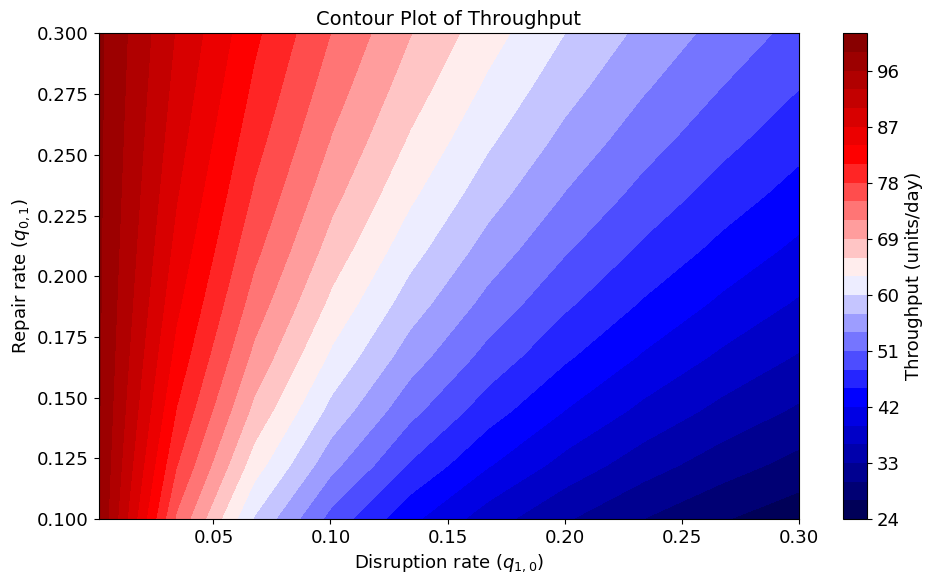

In [74]:
# ========== Plot 2: Throughput ==========
plt.figure(figsize=(10, 6))
cs2 = plt.contourf(Q10, Q01, Throughput_grid, levels=25, cmap="seismic")
plt.colorbar(cs2, label="Throughput (units/day)")
plt.xlabel(r"Disruption rate $(q_{1,0})$")
plt.ylabel(r"Repair rate $(q_{0,1})$")
plt.title("Contour Plot of Throughput")
plt.grid(False)
plt.tight_layout()
plt.savefig("throughput_contour_plot.png", dpi=250, format='png', bbox_inches='tight')
plt.show()

# - Contour Plot for Mean Completion Time

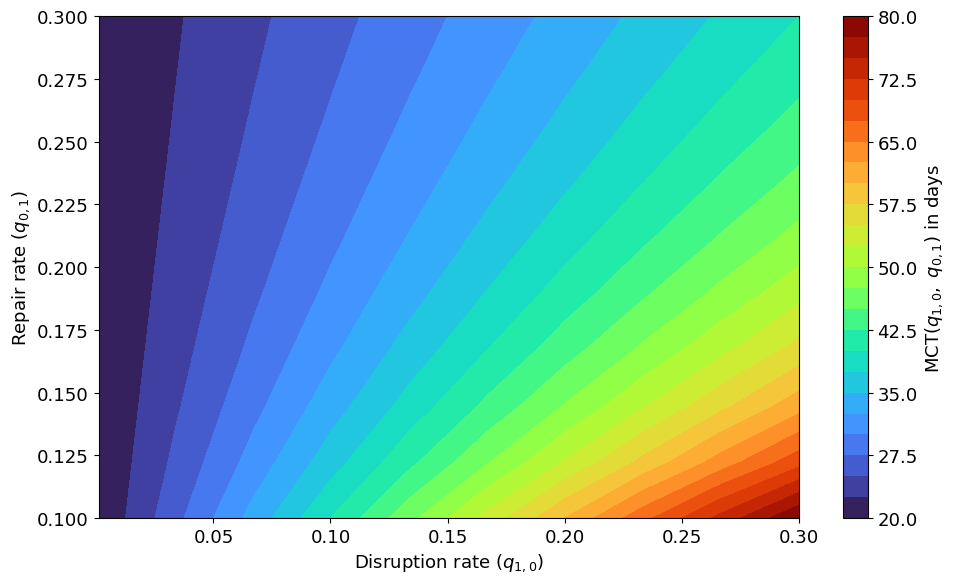

In [75]:
# ========== Plot 3: Mean Completion Time ==========
plt.figure(figsize=(10,6))
cs3 = plt.contourf(Q10, Q01, MeanCompletion_grid, levels=25, cmap="turbo")
plt.colorbar(cs3, label=r"${\rm MCT}\left(q_{1,0},\ q_{0,1}\right)$ in days")
plt.xlabel(r"Disruption rate $(q_{1,0})$")
plt.ylabel(r"Repair rate $(q_{0,1})$")
# plt.title("Contour Plot of Mean Completion Time")
ax.grid(False)
plt.tight_layout()
plt.savefig("mct_contour_plot.png", dpi=250, format='png', bbox_inches='tight')
plt.show()

# - Contour Plot for Expected Time spent in the undisrupted state

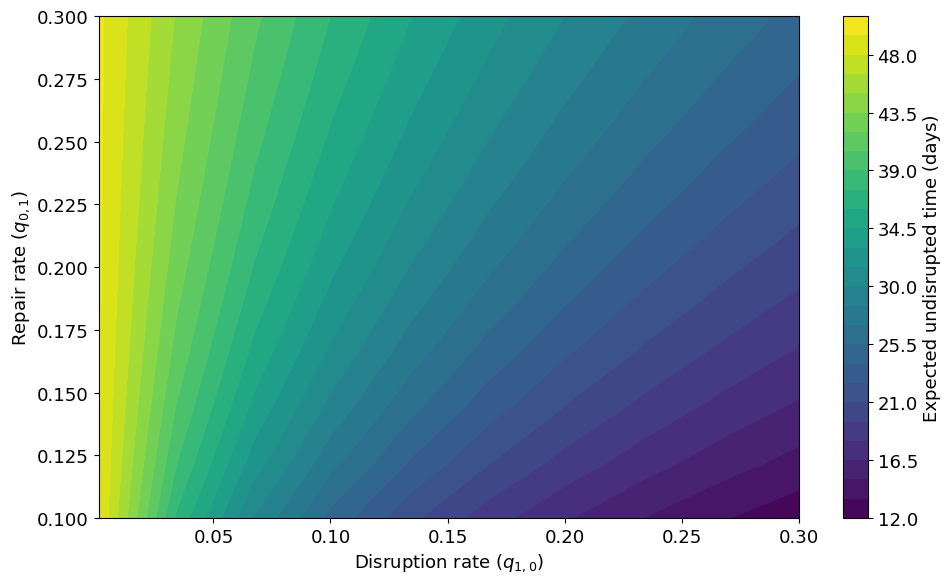

In [14]:
# ========== Plot 4: Expected Time Spent in the Undisrupted state ==========
plt.figure(figsize=(10,6))
cs4 = plt.contourf(Q10, Q01, T_undisrupted_grid, levels=25, cmap="viridis")
plt.colorbar(cs4, label="Expected undisrupted time (days)")
plt.xlabel(r"Disruption rate $(q_{1,0})$")
plt.ylabel(r"Repair rate $(q_{0,1})$")
# plt.title("Contour Plot of Expected Time Spent in the Undisrupted state")
ax.grid(False)
plt.tight_layout()
plt.savefig("expected_undis_time_contour_plot.png", dpi=200, format='png', bbox_inches='tight')

plt.show()

# Expected time line plot and Expected Time contour plot

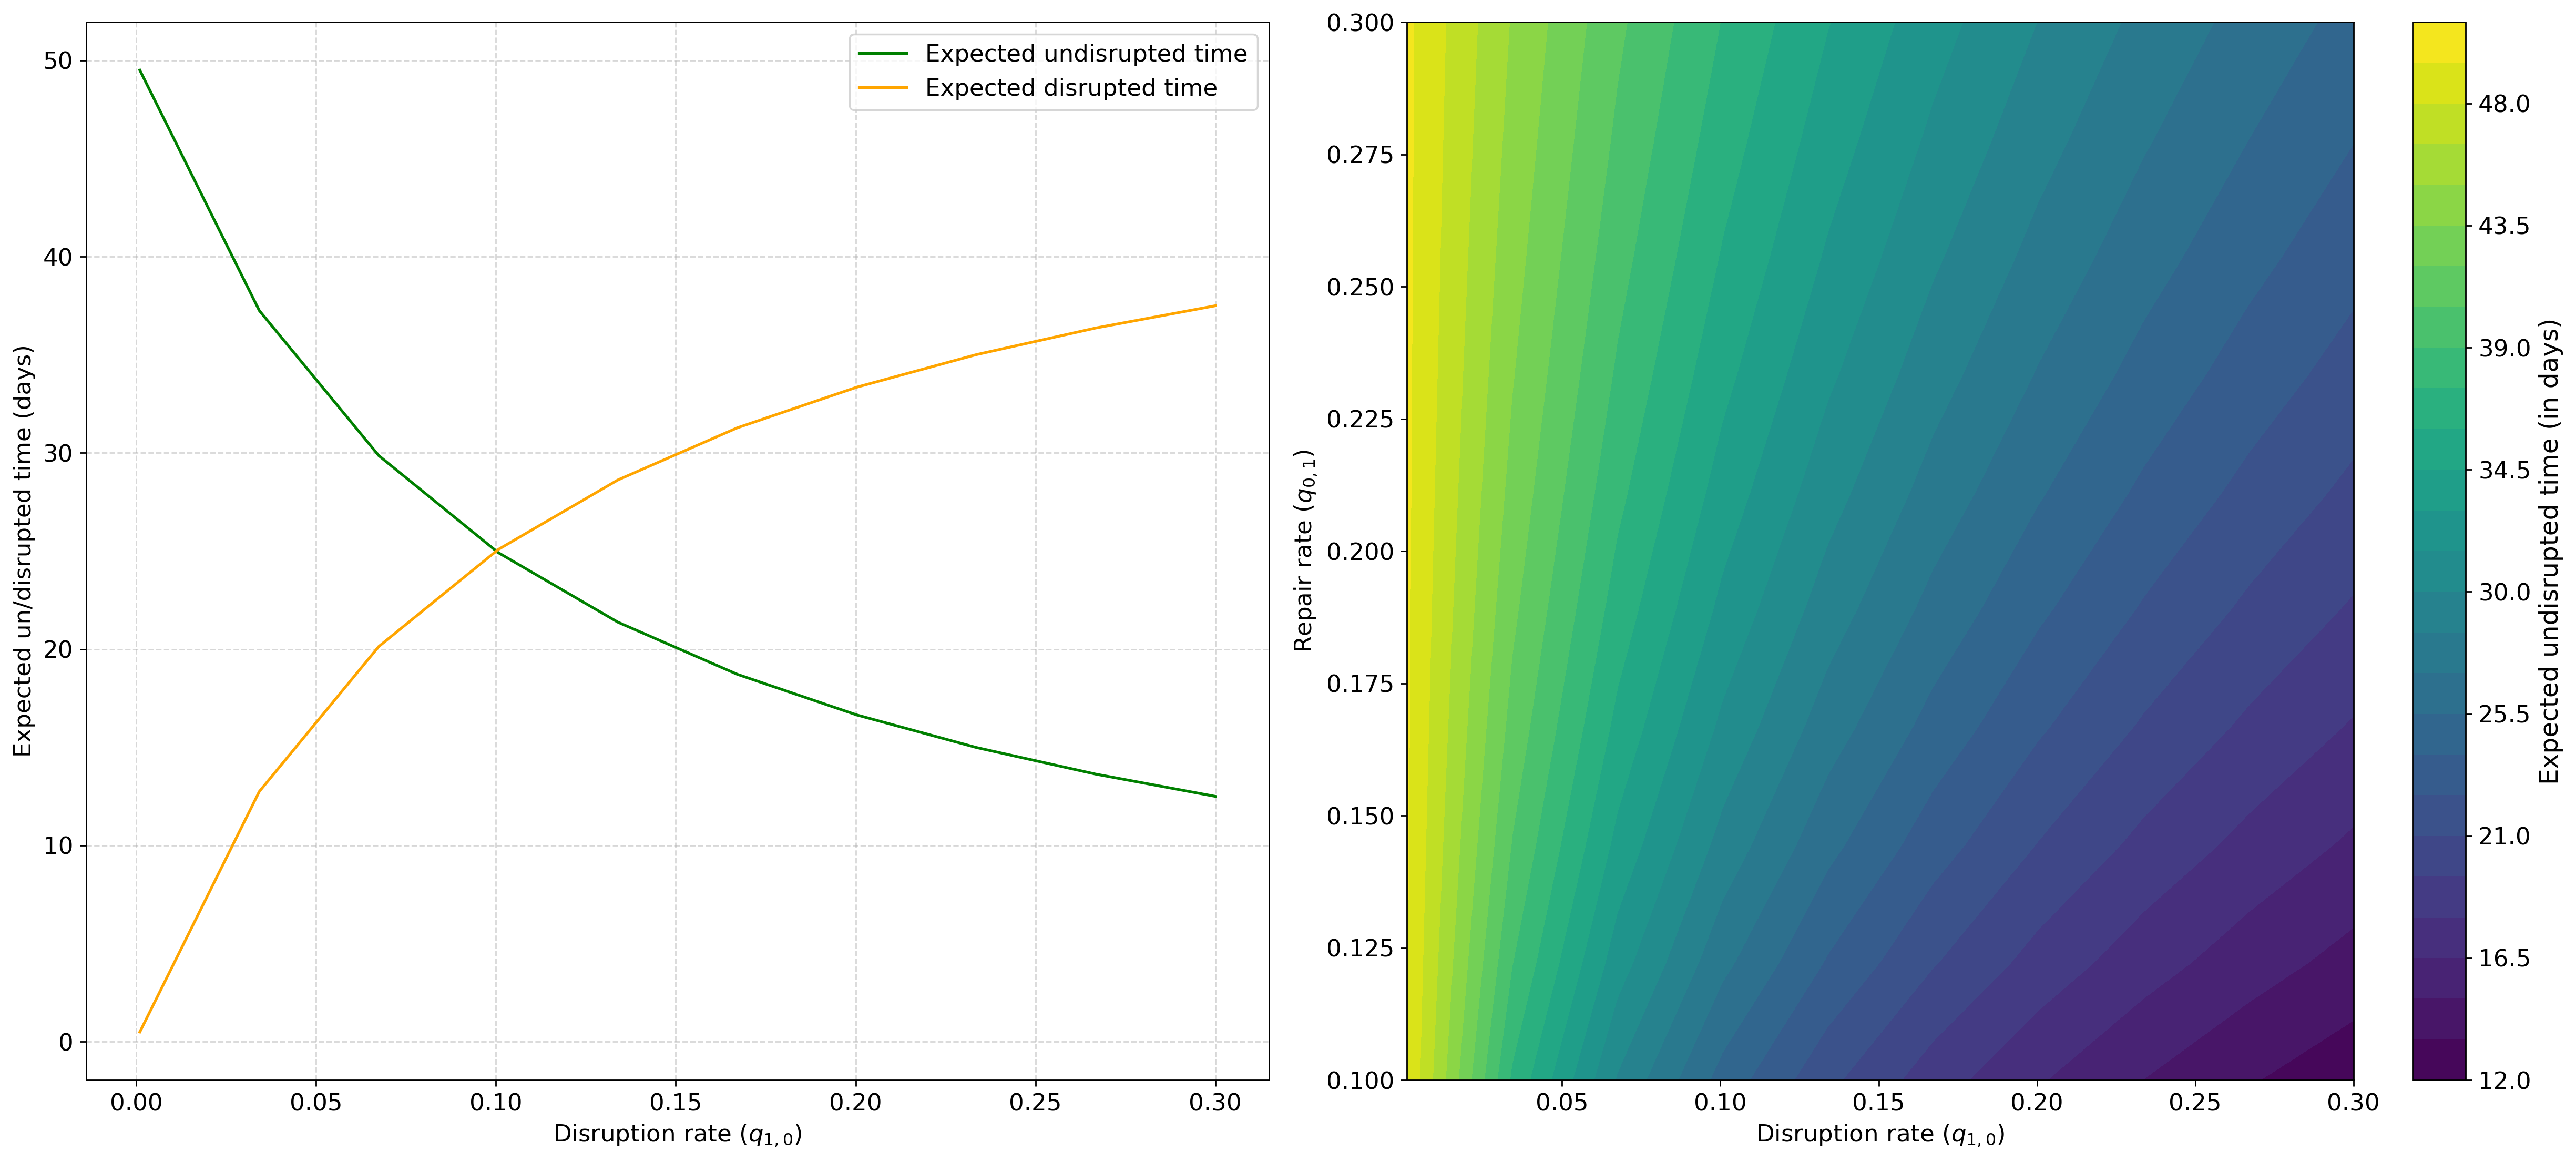

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), dpi=250)

# ============================================================
#  LEFT PANEL — Expected time line plot
# ============================================================
ax = axes[0]

ax.plot(disruption_rates_1, T_undisrupted_list, color="green", linewidth=1.5,label="Expected undisrupted time")
ax.plot(disruption_rates_1, T_disrupted_list, color="orange", linewidth=1.5, label="Expected disrupted time")

ax.set_xlabel(r"Disruption rate ($q_{1,0}$)")
ax.set_ylabel("Expected un/disrupted time (days)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
# ax.set_title("Expected time vs Disruption Rate")


# ============================================================
#  RIGHT PANEL — Expected Time contour plot
# ============================================================
ax = axes[1]

cs4 = ax.contourf(Q10, Q01, T_undisrupted_grid, levels=25, cmap="viridis")
# fig.colorbar(cs4, ax=ax, label="Expected time (days)")
cbar = fig.colorbar(cs4, ax=ax)
cbar.set_label("Expected undisrupted time (in days)", fontsize=14)


ax.set_xlabel(r"Disruption rate $(q_{1,0})$")
ax.set_ylabel(r"Repair rate $(q_{0,1})$")
# ax.set_title("Contour Plot of Expected time (days)")
ax.grid(False)


# ============================================================
#  Formatting
# ============================================================
plt.tight_layout()
plt.savefig("expected_undis_time_line_contour_plot.png", format='png', bbox_inches='tight')
plt.show()


# Throughput, $\mathbb{E}(X_D(T))$ and $\%$Loss

In [8]:
from scipy.stats import norm
T_simulation = 50                                       # total time horizon
production_rate = 100                                    # production rate
target_units = 2000                                      # Targeted output

def sensitivity_analysis_3(q_10, q_01, T_simulation, production_rate, target_units):

    Availability = q_01 /(q_10 + q_01)    
    Throughput = production_rate * Availability
    T_undisrupted = Availability * T_simulation

    # Expected outputs
    ExpectedOutput_disrupted = Throughput * T_simulation                    # E[X_D(T)]
    ExpectedOutput_nominal = production_rate * T_simulation                  # E[X_0(T)]

    # Loss
    Loss = 1 - Availability

    return Throughput, ExpectedOutput_disrupted, ExpectedOutput_nominal, Loss


# Performance metrics across disruption and repair rates

In [102]:

T_simulation = 50
production_rate = 100
target_units = 2000

# Define ranges
disruption_rates = np.linspace(0.01, 10, 5)
repair_rates = np.linspace(0.01, 20, 7)

results = []

for q_01 in repair_rates:
    for q_10 in disruption_rates:

        res = sensitivity_analysis_3(q_10, q_01, T_simulation, production_rate, target_units)

        results.append({
            "q_01": q_01,
            "q_10": q_10,
            "Throughput": res[0],
            "ExpectedOutput_disrupted": res[1],
            "ExpectedOutput_nominal": res[2],
            "Loss": res[3]
        })

df = pd.DataFrame(results)

# df.round(3)

# Throughput table

In [103]:
Throughput_table = df.pivot(index="q_01", columns="q_10", values="Throughput")
print(Throughput_table.round(3))

q_10       0.0100   2.5075   5.0050   7.5025   10.0000
q_01                                                  
0.010000    50.000    0.397    0.199    0.133    0.100
3.341667    99.702   57.131   40.036   30.815   25.047
6.673333    99.850   72.688   57.143   47.075   40.024
10.005000   99.900   79.960   66.656   57.147   50.012
13.336667   99.925   84.174   72.712   63.998   57.149
16.668333   99.940   86.924   76.907   68.961   62.502
20.000000   99.950   88.859   79.984   72.721   66.667


# Expected Output table ($\mathbb{E}X_D(T)$)

In [104]:
ExpectedOutput_table = df.pivot(index="q_01", columns="q_10", values="ExpectedOutput_disrupted")
print(ExpectedOutput_table.round(3))

q_10        0.0100    2.5075    5.0050    7.5025    10.0000
q_01                                                       
0.010000   2500.000    19.861     9.970     6.656     4.995
3.341667   4985.082  2856.532  2001.797  1540.767  1252.342
6.673333   4992.519  3634.383  2857.143  2353.771  2001.200
10.005000  4995.007  3998.002  3332.778  2857.347  2500.625
13.336667  4996.254  4208.699  3635.620  3199.904  2857.449
16.668333  4997.002  4346.182  3845.355  3448.026  3125.117
20.000000  4997.501  4442.963  3999.200  3636.033  3333.333


# \%Loss

In [106]:
Loss_table = df.pivot(index="q_01", columns="q_10", values="Loss")
print(Loss_table.round(4))

q_10       0.0100   2.5075   5.0050   7.5025   10.0000
q_01                                                  
0.010000    0.5000   0.9960   0.9980   0.9987   0.9990
3.341667    0.0030   0.4287   0.5996   0.6918   0.7495
6.673333    0.0015   0.2731   0.4286   0.5292   0.5998
10.005000   0.0010   0.2004   0.3334   0.4285   0.4999
13.336667   0.0007   0.1583   0.2729   0.3600   0.4285
16.668333   0.0006   0.1308   0.2309   0.3104   0.3750
20.000000   0.0005   0.1114   0.2002   0.2728   0.3333
